# 02 - Token Scaling Analysis

Goal: quantify how independent band tokenization grows compared with grouped-band and all-band patch tokenization.

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from dfm.experiments.token_scaling import compare_tokenization

In [6]:
results = compare_tokenization(
    height=1120,
    width=832,
    band_counts=[4, 12, 64, 128, 224],
    patch_sizes=[8, 16, 32, 64],
    group_size=8,
)

df = pd.DataFrame([row.__dict__ for row in results])
df.head()

,strategy,height,width,bands,patch_size,tokens,attention_cost_proxy
0,independent_band,1120,832,4,8,58240,3391897600
1,all_band_patch,1120,832,4,8,14560,211993600
2,grouped_band_8,1120,832,4,8,14560,211993600
3,independent_band,1120,832,4,16,14560,211993600
4,all_band_patch,1120,832,4,16,3640,13249600


In [7]:
view = df[df["patch_size"] == 32]
pivot = view.pivot(index="bands", columns="strategy", values="tokens")
pivot

strategy,all_band_patch,grouped_band_8,independent_band
bands,,,
4,910,910,3640
12,910,1820,10920
64,910,7280,58240
128,910,14560,116480
224,910,25480,203840


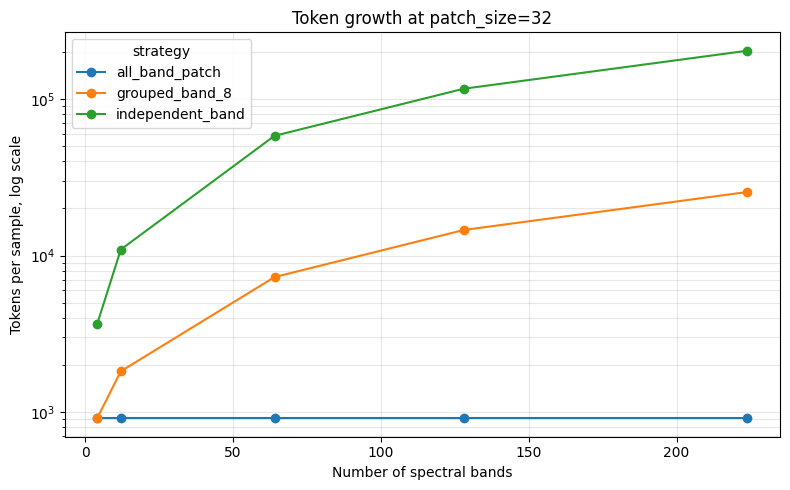

In [8]:
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

pivot.plot(marker="o", figsize=(8, 5))
plt.yscale("log")
plt.xlabel("Number of spectral bands")
plt.ylabel("Tokens per sample, log scale")
plt.title("Token growth at patch_size=32")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "token_growth_patch32.png", dpi=200);


## Attention Cost Proxy

Full self-attention roughly scales as `tokens^2`, so the compute gap becomes much larger than the token-count plot alone suggests.


In [9]:
cost_pivot = view.pivot(index="bands", columns="strategy", values="attention_cost_proxy")
cost_pivot


strategy,all_band_patch,grouped_band_8,independent_band
bands,,,
4,828100,828100,13249600
12,828100,3312400,119246400
64,828100,52998400,3391897600
128,828100,211993600,13567590400
224,828100,649230400,41550745600


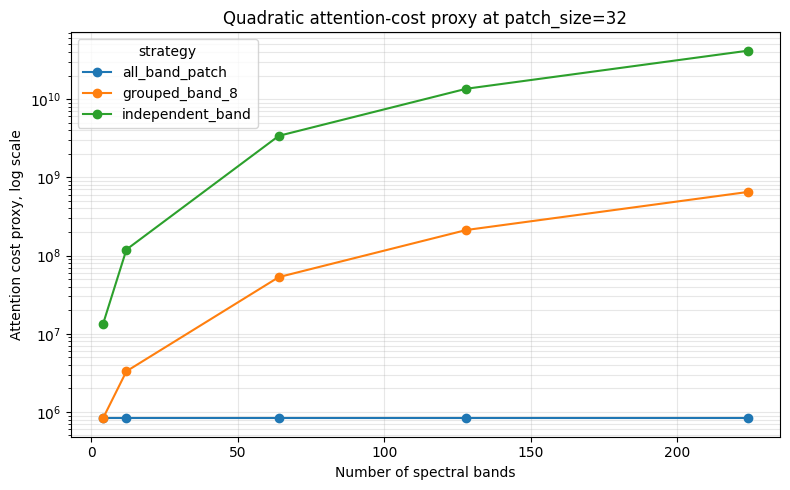

In [10]:
cost_pivot.plot(marker="o", figsize=(8, 5))
plt.yscale("log")
plt.xlabel("Number of spectral bands")
plt.ylabel("Attention cost proxy, log scale")
plt.title("Quadratic attention-cost proxy at patch_size=32")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "attention_cost_proxy_patch32.png", dpi=200);
